<a href="https://colab.research.google.com/github/AndrewP05/Regresion_lineal_multiple/blob/main/Cruzar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Correlación Vial‑Peaje: Identificando Zonas de Alto Riesgo


## Descripcion datos
El presente analisis tiene como fuente dos bases de datos tomadas de la pagina [**Datos Abiertos Colombia**](https://https://www.datos.gov.co/) que nos ayudaran a estudiar, formular y presentar conclusiones sobre la correlacion que puede haber entre las vias nacionales y los peajes.


#### DB - SECTORES CRITICOS DE SINIESTRALIDAD VIAL


*   Ultima Actualizacion: 20 de abril de 2024
*   Fuente: [SECTORES CRITICOS DE SINIESTRALIDAD VIAL](https://www.datos.gov.co/Transporte/SECTORES-CRITICOS-DE-SINIESTRALIDAD-VIAL/rs3u-8r4q/about_data)
*   Diccionario de datos: Tenemos **316** filas y **13** Columnas con:

| Nombre de la columna | Descripción | Tipo de dato               |
|----------------------|-------------|----------------------------|
| `ID_MT`              | Identificador vía Ministerio de Transporte             | Texto                                    |
| `ENTIDAD`            | Entidad a cargo de la Vía | Texto        |
| `GiZScore`           | Calificación según análisis espacial     |  Número                 |
| `Fallecidos`         | Cantidad de fallecidos en el sector      | Número                 |
| `GiPValue`           | Probabilidad de ocurrencia en el sector  | Número                 |
| `Tramo`              | Identificación de la vía en una longitud determinada            | Texto                                    |
| `Nombre`             | Nombre de vía concesionada               |   Texto                  |
| `Latitud`            | Coordenada geográfica respecto al norte  |  Número                 |
| `Longitud`           | Coordenada geográfica respecto al este   | Número                 |
| `PR`                 | Punto de referencia en la vía            |  Texto                  |
| `Municipio`          | Municipio ente territorial               |  	Texto                  |
| `Departamento`       | Departamento ente territorial            |  	Texto                  |
| `divipola`           | Código división política                 |  Texto                  |


#### DB - PEAJES


*   Ultima Actualizacion: 7 de marzo de 2025
*   Fuente: [SECTORES CRITICOS DE SINIESTRALIDAD VIAL](https://www.datos.gov.co/Transporte/Peajes/68qj-5xux/about_data)
*   Diccionario de datos: Tenemos **181** filas y **44** Columnas con:

| Nombre de la columna   | Descripción    | Tipo de dato    |
|--------------|--------------|--------------|
| `point `            |  Coordenadas           |  Punto            |
| 	`nombre_peaje`            | 	Nombre del Peaje             | 	Texto             |
|  	`ubicaci_n`           |  Ubicación            | 	Texto             |
| `sector`             |   Sector           |   	Texto           |
| 	`sentido`             |   	Sentido           |   	Texto           |
| 	`poste_de_referencia_pr`             | Poste de Referencia              | 	Número             |
| 	`distancia_pr`             |  Distancia al Poste de Referencia            |  	Número            |
| 	`telefono_gr_a`             |  	Telefono de la Grua            |   	Texto           |
| `telefono_peaje`             | 	Telefono del Peaje             |  	Texto            |
| 	`url_foto`             | 	Link Foto             |  	URL            |
|  `categoria_i` al `categoria_viie`            |Categoria             |  	Número            |
| `administrador`             | Administrador del Peaje.              |    Número          |
| 	`c_digo_peaje`             |  Código del Peaje            |  	Número            |
| `c_digo_tramo`             |  Código Tramo            |  	Texto            |
|  `eje_adicional`            | 	Eje Adicional             |  	Número            |
| `eje_adicional_r`             |  	Eje Adicional R            |	Número              |
|  	`eje_grua`            | Eje Grua             |  Número            |
|  	`latitud`            |   Latitud           |  	Número            |
| 	`longitud`             |  Longitud            |  Número            |
|    `responsable`          |   Responsable           | 	Texto             |
|    `territorial`         |   	Dominio Territorial            | 		Número             |


## Objetivos

### General

1. Analizar la relación entre la ubicación de los peajes y los sectores críticos de siniestralidad vial para identificar patrones, zonas de riesgo y posibles factores asociados a los accidentes de tránsito en las vías analizadas.

### Especificos

1. Identificar la proximidad geográfica entre peajes y sectores críticos de siniestralidad vial.
2. Clasificar los sectores críticos según su distancia a los peajes.
3. Generar insights y hallazgos relevantes para la toma de decisiones.

## Preguntas de negocio

1. ¿En qué Peajes se concentran las tarifas más altas y las mas bajas?
2. ¿Influye la distacia del peaje en la concentracion de siniestros viales?
3. ¿Que peajes tienen mas siniestros asociados?
4. ¿Qué peajes registran un promedio de fallecidos por siniestro más elevado?

### Instalamos las librerias necesarias

In [2]:
!pip install pandas

### Conectamos colab con drive para cargar datos

In [3]:
# @title
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Importamos la libreria pandas y cargamos el archivo Sectores Criticos De Siniestralidad Vial

In [4]:
import pandas as pd

# Cargar los archivos (esto ya lo hiciste antes, lo dejo aquí para contexto)
df_siniestros = pd.read_csv("/content/drive/MyDrive/Semestre 8/Data Analytics/Taller/SECTORES_CRITICOS_DE_SINIESTRALIDAD_VIAL_20250407.csv")
df_siniestros

,ID_MT,ENTIDAD,GiZScore,Fallecidos,GiPValue,Tramo,Nombre,Latitud,Longitud,PR,Municipio,Departamento,divipola
0,4G013,ANI,1.771262,11,0.076517,Bogotá - Villavicencio,IP – Chirajara - Fundadores,4.452987,-74.046677,10,CHIPAQUE,CUNDINAMARCA,25178
1,4G013,ANI,3.818008,23,0.000135,Bogotá - Villavicencio,IP – Chirajara - Fundadores,4.228251,-73.818342,58,GUAYABETAL,CUNDINAMARCA,25335
2,4G013,ANI,2.796662,1,0.005163,Bogotá - Villavicencio,IP – Chirajara - Fundadores,4.203601,-73.807188,60,GUAYABETAL,CUNDINAMARCA,25335
3,4G013,ANI,1.725132,1,0.084504,Bogotá - Villavicencio,IP – Chirajara - Fundadores,4.121453,-73.643971,85,VILLAVICENCIO,META,50001
4,4G020,ANI,1.934420,4,0.053062,Villavicencio - Yopal,Villavicencio - Yopal,4.201806,-73.592214,8,RESTREPO,META,50606
...,...,...,...,...,...,...,...,...,...,...,...,...,...
136,3G012,ANI,2.699465,12,0.006945,Bosconia - Cienaga,Ruta del Sol 3,9.780252,-73.748405,62,EL PASO,CESAR,20250
137,4G026,ANI,6.546778,25,0.000000,Chigorodó-Turbo,Autopistas al Mar 2,8.005361,-76.640697,16,TURBO,ANTIOQUIA,5837
138,3G012,ANI,2.403517,11,0.016238,Bosconia - Cienaga,Ruta del Sol 3,10.310160,-74.046928,8,ALGARROBO,MAGDALENA,47030
139,4G016,ANI,2.699465,12,0.006945,San Pelayo-Lorica,IP – Antioquia – Bolívar,9.030229,-75.827469,25,COTORRA,CÓRDOBA,23300


### Cargamos el archivo Peajes

In [5]:
df_peajes = pd.read_csv("/content/drive/MyDrive/Semestre 8/Data Analytics/Taller/Peajes_20250407.csv")
df_peajes

,point,Nombre Peaje,Ubicación,Sector,Sentido,Poste de Referencia PR,Distancia PR,Telefono Grúa,Telefono Peaje,URL Foto,...,Administrador,Código Peaje,Código Tramo,Eje Adicional,Eje Adicional R,Eje Grua,Latitud,Longitud,Responsable,Territorial
0,POINT (-76.32849669799998 3.995509249000065),RÍO FRÍO,Vía Mediacanoa - Ansermanuevo Km 13,Mediacanoa - Ansermanuevo,Norte – Sur / Sur - Norte,13,420,Por Definir,3102454252,https://hermes.invias.gov.co/recursos/Fichas%2...,...,1.0,4.0,2302,10900,10500,8000,3.995509,-76.328497,INVIAS,25
1,POINT (-75.77560327799995 5.33243849400003),SAN CLEMENTE,Vía Cauyá - El Palo,Cauyá - La Felisa,Ambos sentidos de circulación,17,150,Por Definir,3102454264,https://hermes.invias.gov.co/recursos/Fichas%2...,...,1.0,21.0,2508,10900,10500,8000,5.332438,-75.775603,INVIAS,5
2,POINT (-72.99948186899996 6.825634367000021),LOS CUROS,Vía San Gil - Bucaramanga Km 53+730 Jurisdicci...,San Gil - Bucaramanga,Aplica en ambos sentidos,53,730,Por Definir,Por Definir,https://hermes.invias.gov.co/recursos/Fichas%2...,...,1.0,85.0,45A07,12400,12200,8500,6.825634,-72.999482,INVIAS,22
3,POINT (-73.91282774399997 5.104394194000065),CASABLANCA,Cogua – Tausa Km 40+000,Bogotá - Ubaté,Sur – Norte // Norte – Sur,40,0,Por Definir,Por Definir,https://hermes.invias.gov.co/recursos/Fichas%2...,...,1.0,81.0,45A04,12400,12200,8500,5.104394,-73.912828,INVIAS,12
4,POINT (-73.50115777799994 5.557684876000053),SÁCHICA,Vía Chiquinquirá Tunja km 42+800 Jurisdicción ...,Sáchica - Tunja,Ambos sentidos de circulación,50,200,Por Definir,3102455356,https://hermes.invias.gov.co/recursos/Fichas%2...,...,1.0,113.0,6008,10900,10500,8000,5.557685,-73.501158,INVIAS,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
176,POINT (-73.66972199999998 8.852804000000049),PAILITAS,Km 28+500 Vía La Mata – San Roque,La Mata - San Roque,Norte – Sur – Norte,28,600,NaN,3165280395,https://hermes.invias.gov.co/recursos/Fichas%2...,...,2.0,75.0,4515,11000,10800,7800,8.852804,8.852804,INVÍAS,9
177,POINT (-73.63943499999993 9.638003000000026),LA LOMA,Km 42 Vía San Roque - Bosconia,San Roque - Bosconia,Sur – Norte,40,1927,018000945566 Opción 1,3158210547,http://hermes.invias.gov.co/carreteras/images/...,...,2.0,76.0,4516,9000,8700,6500,9.638017,9.638017,Concesión Yuma,9
178,POINT (-73.54651899999999 7.397176000000059),LA GÓMEZ,Vía La Lizama – San Alberto Km 37 + 300,Cruce Ruta 45 (La Fortuna) - Lebrija,Sur – Norte,37,300,Por Definir,Por Definir,https://hermes.invias.gov.co/recursos/Fichas%2...,...,2.0,126.0,6602,11000,10800,7800,7.397176,7.397176,INVIAS,22
179,POINT (-72.30502163899996 5.410988727000074),ARANGUANEY (NO OPERATIVO),Via Sogamoso Yopal Km 8+900 Jurisdiccion Soga...,Sogamoso - El Crucero,Bidireccional,16,800,Por Definir,Por Definir,NaN,...,1.0,NaN,6513,0,0,2400,5.410989,5.410989,INVÍAS,7


### 1. ¿En qué Peajes se concentran las tarifas más altas y las mas bajas?

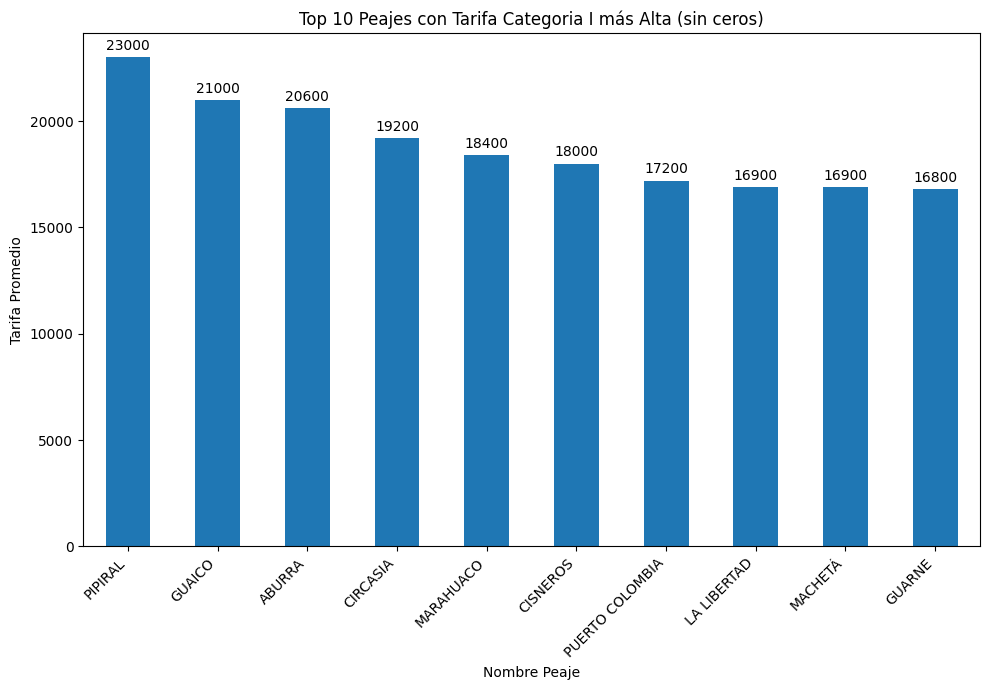

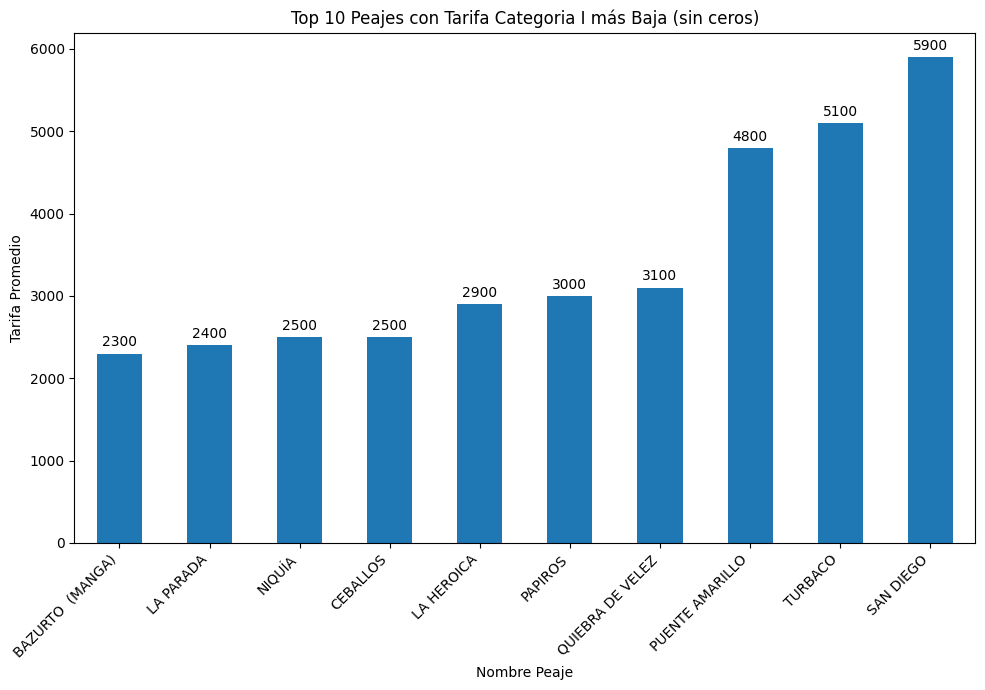

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Filtrar solo valores de 'Categoria I' mayores que 0
df_nonzero = df_peajes[df_peajes['Categoria I'] > 0]

# 2. Agrupar por 'Nombre Peaje' y calcular la tarifa promedio
tarifas = df_nonzero.groupby('Nombre Peaje')['Categoria I'].mean()

# 3. Top 10 más alto y Top 10 más bajo
top_high = tarifas.sort_values(ascending=False).head(10)
top_low  = tarifas.sort_values(ascending=True).head(10)

# --------------------------------------------------
# 4. Gráfico: Top 10 Peajes con tarifa más alta
plt.figure(figsize=(10, 7))
ax = top_high.plot(kind='bar')
plt.title('Top 10 Peajes con Tarifa Categoria I más Alta (sin ceros)')
plt.xlabel('Nombre Peaje')
plt.ylabel('Tarifa Promedio')
plt.xticks(rotation=45, ha='right')

# Etiquetas sobre cada barra
for bar in ax.patches:
    y = bar.get_height()
    ax.annotate(
        f'{y:.0f}',
        xy=(bar.get_x() + bar.get_width() / 2, y),
        xytext=(0, 3),
        textcoords='offset points',
        ha='center', va='bottom'
    )

plt.tight_layout()
plt.show()


print("\n")
# --------------------------------------------------
# 5. Gráfico: Top 10 Peajes con tarifa más baja
plt.figure(figsize=(10, 7))
ax = top_low.plot(kind='bar')
plt.title('Top 10 Peajes con Tarifa Categoria I más Baja (sin ceros)')
plt.xlabel('Nombre Peaje')
plt.ylabel('Tarifa Promedio')
plt.xticks(rotation=45, ha='right')

# Etiquetas sobre cada barra
for bar in ax.patches:
    y = bar.get_height()
    ax.annotate(
        f'{y:.0f}',
        xy=(bar.get_x() + bar.get_width() / 2, y),
        xytext=(0, 3),
        textcoords='offset points',
        ha='center', va='bottom'
    )

plt.tight_layout()
plt.show()


A partir de las anteriores gráficas, podemos concluir que los peajes con tarifa más altas se ubican entre los 16.800 y los 23.000 pesos, donde encabeza **Pimpal**, **Guacio** y **Aburra**. Los peajes con tarifas más bajas oscilan entre los 2.300 y 5.900 pesos, donde destacan **Baluarte**, **La parada** y **Nuña**.

El contraste entre ambos grupos es significativo, pues las tarifas más altas pueden ser hasta diez veces mayores que las más bajas, lo cual sugiere diferencias sustanciales de costo según la ubicación, operación de cada peaje y un posible indicio de si es o no causal de siniestros viales.

### 2. ¿Influye la distacia del peaje en la concentracion de siniestros viales?

In [7]:
# Seleccionar solo las columnas necesarias
df_siniestros = df_siniestros[['Latitud', 'Longitud', 'Fallecidos', 'Tramo']]
df_peajes = df_peajes[['Latitud', 'Longitud', 'Nombre Peaje']]

# Crear una lista para guardar la distancia mínima a cada peaje
distancias = []

# Usamos solo pandas para recorrer los dataframes
for i in df_siniestros.index:
    lat_s = df_siniestros.at[i, 'Latitud']
    lon_s = df_siniestros.at[i, 'Longitud']

    # Creamos una copia del DataFrame de peajes para calcular distancia a este siniestro
    df_temp = df_peajes.copy()
    df_temp['Distancia'] = ((df_temp['Latitud'] - lat_s)**2 + (df_temp['Longitud'] - lon_s)**2)**0.5

    # Agregar la distancia mínima a la lista
    distancias.append(df_temp['Distancia'].min())

# Agregar la distancia mínima como nueva columna
df_siniestros['Distancia al Peaje'] = distancias

# Crear rangos de distancia
bins = [0, 0.01, 0.05, 0.1, 0.2, 0.5, 1, 5]
labels = ['<1 km', '1-5 km', '5-10 km', '10-20 km', '20-50 km', '50-100 km', '100-500 km']
df_siniestros['Rango de Distancia'] = pd.cut(df_siniestros['Distancia al Peaje'], bins=bins, labels=labels)

# Agrupar y contar fallecidos por rango
resultado = df_siniestros.groupby('Rango de Distancia')['Fallecidos'].sum().reset_index()

# Mostrar el resultado
print(resultado)

  Rango de Distancia  Fallecidos
0              <1 km           0
1             1-5 km          10
2            5-10 km           0
3           10-20 km          58
4           20-50 km         364
5          50-100 km         586
6         100-500 km         527


/tmp/ipykernel_1397/2966677412.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_siniestros['Distancia al Peaje'] = distancias
/tmp/ipykernel_1397/2966677412.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_siniestros['Rango de Distancia'] = pd.cut(df_siniestros['Distancia al Peaje'], bins=bins, labels=labels)
/tmp/ipykernel_1397/2966677412.py:29: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain c

<Axes: title={'center': 'Fallecidos por peaje más cercano'}, xlabel='Nombre del peaje', ylabel='Cantidad de fallecidos'>

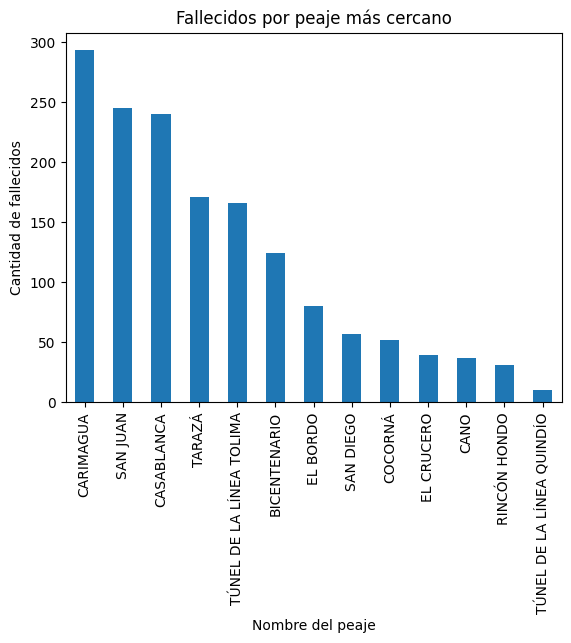

In [8]:
# Crear una copia de df_siniestros para no modificar el original
df_siniestros_copia = df_siniestros.copy()

# Crear una columna para almacenar el peaje más cercano
df_siniestros_copia['Nombre Peaje'] = None

# Para cada siniestro, encontrar el peaje más cercano por diferencia de coordenadas
for idx, siniestro in df_siniestros_copia.iterrows():
    lat_s, lon_s = siniestro['Latitud'], siniestro['Longitud']

    # Crear copia temporal de df_peajes con columna de diferencia
    peajes_temp = df_peajes.copy()
    peajes_temp['Diferencia'] = (peajes_temp['Latitud'] - lat_s).abs() + (peajes_temp['Longitud'] - lon_s).abs()

    # Obtener el nombre del peaje más cercano
    peaje_mas_cercano = peajes_temp.loc[peajes_temp['Diferencia'].idxmin(), 'Nombre Peaje']

    # Asignar el nombre del peaje al siniestro
    df_siniestros_copia.at[idx, 'Nombre Peaje'] = peaje_mas_cercano

# Agrupar por Nombre Peaje y sumar fallecidos
resultado = df_siniestros_copia.groupby('Nombre Peaje')['Fallecidos'].sum().reset_index()

# Ordenar de mayor a menor
resultado = resultado.sort_values(by='Fallecidos', ascending=False)

# Graficar con pandas
resultado.plot(kind='bar',
               x='Nombre Peaje',
               y='Fallecidos',
               legend=False,
               title='Fallecidos por peaje más cercano',
               xlabel='Nombre del peaje',
               ylabel='Cantidad de fallecidos')



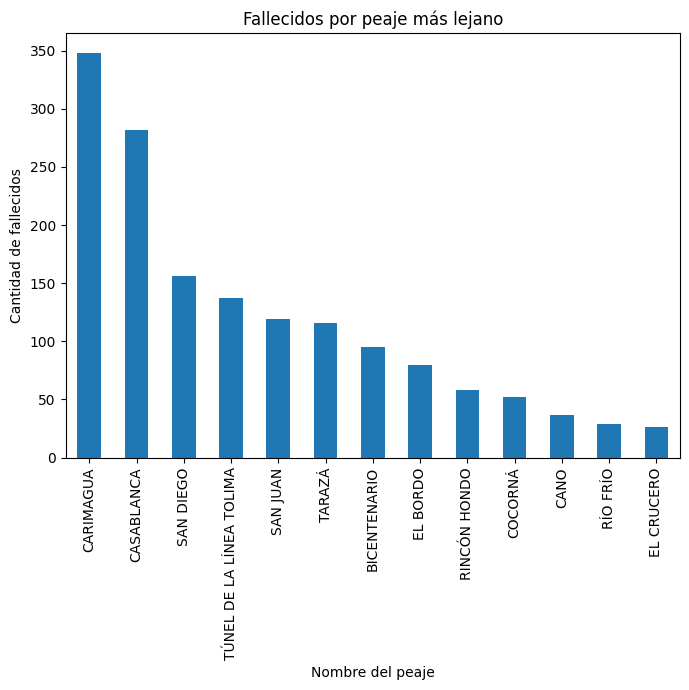

In [9]:
import pandas as pd

# 1) Preparar los dataframes
df_sini = df_siniestros[['Latitud','Longitud','Fallecidos']].copy()
df_peaj = df_peajes[['Latitud','Longitud','Nombre Peaje']].copy()

# 2) Para cada siniestro, asignar el peaje más cercano y la distancia euclídea
df_sini['Peaje_cercano'] = None
df_sini['Distancia']      = None

for idx, row in df_sini.iterrows():
    lat_s, lon_s = row['Latitud'], row['Longitud']
    # calculamos distancias euclídeas a todos los peajes
    df_peaj['Dist_tmp'] = ((df_peaj['Latitud'] - lat_s)**2 +
                          (df_peaj['Longitud'] - lon_s)**2)**0.5
    # seleccionamos el más cercano
    i_min = df_peaj['Dist_tmp'].idxmin()
    df_sini.at[idx, 'Peaje_cercano'] = df_peaj.at[i_min, 'Nombre Peaje']
    df_sini.at[idx, 'Distancia']      = df_peaj.at[i_min, 'Dist_tmp']

# 3) Agrupar por peaje: sumar fallecidos y calcular distancia media
stats = ( df_sini
          .groupby('Peaje_cercano')
          .agg(Fallecidos=('Fallecidos','sum'),
               Dist_media=('Distancia','mean'))
          .reset_index() )

# 4) Seleccionar los 13 peajes más “lejanos” (mayor distancia media)
top13 = stats.sort_values('Dist_media', ascending=False).head(13)

# --- Nuevo paso: ordenar por Fallecidos de mayor a menor ---
top13 = top13.sort_values('Fallecidos', ascending=False)

# 5) Graficar con pandas
ax = top13.plot(
    kind='bar',
    x='Peaje_cercano',
    y='Fallecidos',
    legend=False,
    figsize=(7, 7),
    rot=90,
    title='Fallecidos por peaje más lejano',
    xlabel='Nombre del peaje',
    ylabel='Cantidad de fallecidos'

)

# Opcional: ajustar layout para que no se corte
fig = ax.get_figure()
fig.tight_layout()


En el análisis de fallecidos por peaje más cercano, se observó que algunos peajes están más asociados a siniestros graves, ya que presentan un mayor número de fallecidos. Este hallazgo puede reflejar que ciertos peajes están ubicados en áreas más peligrosas o con mayor tránsito, lo que incrementa la probabilidad de accidentes graves. La concentración de fallecidos en ciertos peajes sugiere que es necesario un análisis más detallado de las condiciones de esas zonas, como el tipo de carretera, la visibilidad, la señalización y otros factores de seguridad vial.

### 3. ¿Que peajes tienen mas siniestros asociados?

In [10]:
# Redondear coordenadas para emparejar siniestros y peajes cercanos
df_siniestros['Lat_rounded'] = df_siniestros['Latitud'].round(2)
df_siniestros['Lon_rounded'] = df_siniestros['Longitud'].round(2)

df_peajes['Lat_rounded'] = df_peajes['Latitud'].round(2)
df_peajes['Lon_rounded'] = df_peajes['Longitud'].round(2)

# Merge de ambos DataFrames usando coordenadas redondeadas
df_merged = pd.merge(df_siniestros, df_peajes, on=['Lat_rounded', 'Lon_rounded'], how='inner')


/tmp/ipykernel_1397/3174599335.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_siniestros['Lat_rounded'] = df_siniestros['Latitud'].round(2)
/tmp/ipykernel_1397/3174599335.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_siniestros['Lon_rounded'] = df_siniestros['Longitud'].round(2)
/tmp/ipykernel_1397/3174599335.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the docume

<Axes: title={'center': 'Cantidad de siniestros por peaje'}, xlabel='Peaje', ylabel='Cantidad de Siniestros'>

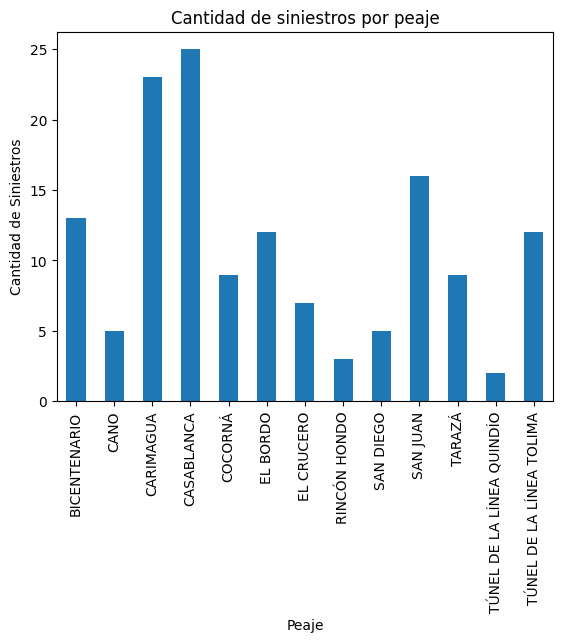

In [11]:
# Crear una copia de df_siniestros para no modificar el original
df_siniestros_copia = df_siniestros.copy()

# Crear una columna para almacenar el peaje más cercano
df_siniestros_copia['Nombre Peaje'] = None

# Para cada siniestro, encontrar el peaje más cercano por diferencia de coordenadas
for idx, siniestro in df_siniestros_copia.iterrows():
    lat_s, lon_s = siniestro['Latitud'], siniestro['Longitud']

    # Crear copia temporal de df_peajes con columna de diferencia
    peajes_temp = df_peajes.copy()
    peajes_temp['Diferencia'] = (peajes_temp['Latitud'] - lat_s).abs() + (peajes_temp['Longitud'] - lon_s).abs()

    # Obtener el nombre del peaje más cercano
    peaje_mas_cercano = peajes_temp.loc[peajes_temp['Diferencia'].idxmin(), 'Nombre Peaje']

    # Asignar el nombre del peaje al siniestro
    df_siniestros_copia.at[idx, 'Nombre Peaje'] = peaje_mas_cercano

# Agrupar por Nombre Peaje y contar siniestros
conteo_siniestros = df_siniestros_copia.groupby('Nombre Peaje').size().reset_index(name='Cantidad de Siniestros')

# Graficar con pandas
conteo_siniestros.plot(kind='bar', x='Nombre Peaje', y='Cantidad de Siniestros', legend=False,
                       title='Cantidad de siniestros por peaje', xlabel='Peaje', ylabel='Cantidad de Siniestros')


De acuerdo con la gráfica, los peajes con mayor número de siniestros asociados son Carimagua y Casablanca, seguidos por Bicentenario en un segundo lugar notable. El resto de peajes muestran concentraciones de siniestros menores, indicando que los esfuerzos de control y prevención podrían priorizarse en los corredores viales de Carimagua y Casablanca para mitigar y reducir estos incidentes.


### 4. ¿Qué peajes registran un promedio de fallecidos por siniestro más elevado?

/tmp/ipykernel_1397/1663213648.py:22: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  promedio_fallecidos = df_siniestros_copia.groupby('Nombre Peaje').apply(lambda x: x['Fallecidos'].sum() / len(x)).reset_index(name='Promedio de Fallecidos')


[Text(-2.0, 0, 'TÚNEL DE LA LÍNEA QUINDÍO'),
 Text(0.0, 0, 'BICENTENARIO'),
 Text(2.0, 0, 'CARIMAGUA'),
 Text(4.0, 0, 'COCORNÁ'),
 Text(6.0, 0, 'EL CRUCERO'),
 Text(8.0, 0, 'SAN DIEGO'),
 Text(10.0, 0, 'TARAZÁ'),
 Text(12.0, 0, 'TÚNEL DE LA LÍNEA TOLIMA'),
 Text(14.0, 0, '')]

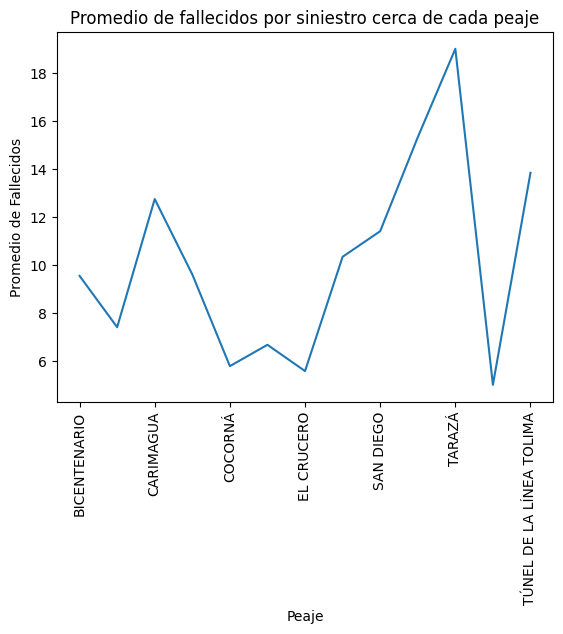

In [12]:
# Crear una copia de df_siniestros para no modificar el original
df_siniestros_copia = df_siniestros.copy()

# Crear una columna para almacenar el peaje más cercano
df_siniestros_copia['Nombre Peaje'] = None

# Para cada siniestro, encontrar el peaje más cercano por diferencia de coordenadas
for idx, siniestro in df_siniestros_copia.iterrows():
    lat_s, lon_s = siniestro['Latitud'], siniestro['Longitud']

    # Crear copia temporal de df_peajes con columna de diferencia
    peajes_temp = df_peajes.copy()
    peajes_temp['Diferencia'] = (peajes_temp['Latitud'] - lat_s).abs() + (peajes_temp['Longitud'] - lon_s).abs()

    # Obtener el nombre del peaje más cercano
    peaje_mas_cercano = peajes_temp.loc[peajes_temp['Diferencia'].idxmin(), 'Nombre Peaje']

    # Asignar el nombre del peaje al siniestro
    df_siniestros_copia.at[idx, 'Nombre Peaje'] = peaje_mas_cercano

# Calcular el promedio de fallecidos por siniestro cerca de cada peaje
promedio_fallecidos = df_siniestros_copia.groupby('Nombre Peaje').apply(lambda x: x['Fallecidos'].sum() / len(x)).reset_index(name='Promedio de Fallecidos')

# Graficar con pandas
ax = promedio_fallecidos.plot(kind='line', x='Nombre Peaje', y='Promedio de Fallecidos', legend=False,
                               title='Promedio de fallecidos por siniestro cerca de cada peaje', xlabel='Peaje', ylabel='Promedio de Fallecidos')

# Rotar etiquetas del eje x a 90 grados (vertical)
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


En cuanto al promedio de fallecidos por siniestro cerca de cada peaje, los resultados mostraron que algunos peajes tienen un mayor promedio de fallecidos por accidente en comparación con otros. Esto puede ser un indicio de que, en determinadas áreas, los accidentes tienden a ser más graves, lo que podría estar relacionado con factores como la velocidad en esas zonas, el diseño de las carreteras o la falta de medidas de seguridad adecuadas. Estos datos son esenciales para priorizar acciones preventivas que no solo aborden la cantidad de siniestros, sino también la gravedad de los mismos.

## Conclusiones

Los análisis realizados sobre la relación entre los siniestros y los peajes cercanos proporcionan una comprensión valiosa de los puntos críticos en la red vial. Al estudiar la cantidad de fallecidos, la frecuencia de los siniestros y el promedio de fallecidos por accidente en la cercanía de cada peaje, se identificaron áreas con mayor riesgo, tanto en términos de la cantidad de accidentes como en su gravedad. Este tipo de análisis es fundamental para priorizar intervenciones en zonas de alto riesgo y mejorar la seguridad vial.

Entre los hallazgos relevantes se destacan:

* Identificación de Zonas Críticas:
Los peajes que se encuentran próximos a zonas con mayor número de siniestros o fallecidos fueron identificados como áreas críticas. La concentración de siniestros en determinadas ubicaciones resalta la importancia de revisar las condiciones de la infraestructura vial en estos puntos.

* Evaluación del Impacto en la Gravedad de los Accidentes:
El análisis del promedio de fallecidos por siniestro permitió identificar aquellos peajes en los que, aunque la frecuencia de accidentes pudiera ser moderada, la gravedad de los mismos es mayor. Esto sugiere la necesidad de medidas específicas para mitigar la severidad de los accidentes, más allá de simplemente reducir su ocurrencia.

* Priorización de Intervenciones:
Los resultados obtenidos permiten orientar la planificación de políticas de seguridad vial, dirigiendo recursos y esfuerzos a aquellas zonas en las que tanto la cantidad como la gravedad de los siniestros alcanzan niveles críticos. Entre las medidas recomendadas se encuentran la revisión de la señalización, la implementación de controles de velocidad, mejoras en la iluminación y en el estado de la carretera.

* Importante Observación:
A partir de los datos analizados, se concluye que no existe una relación directa entre el costo del peaje y la cantidad o gravedad de los siniestros. En otras palabras, el valor cobrado en el peaje no se correlaciona de forma sistemática con el riesgo o la frecuencia de accidentes en sus cercanías. Esta conclusión enfatiza que otros factores —como el volumen de tráfico, las condiciones geomorfológicas del trayecto, la calidad de la infraestructura, entre otros— resultan ser mucho más determinantes en el nivel de siniestralidad.










## Bibliografia

Base de datos - Sectores Criticos De Siniestralidad vial: [Link](https://www.datos.gov.co/Transporte/SECTORES-CRITICOS-DE-SINIESTRALIDAD-VIAL/rs3u-8r4q/data_preview)

Base de datos - Peajes: [Link](https://www.datos.gov.co/Transporte/Peajes/68qj-5xux/data_preview)

Pandas: [Link](https://pandas.pydata.org/)

## Autores

Andres Santiago Puentes Munevar

Juan David Ramirez Marin

Realizado el 10/04/2025 - Data analytics

